# Exercise 1.2 — Predict house prices (Keras MLP regression)

First contact with Keras: a two-layer Multi-Layer Perceptron predicting house prices from tabular features. We jump straight in before discussing hyperparameters in depth — the goal is to see the workflow end to end.

> Dataset note: the old version of this exercise used the Boston housing dataset (506 samples, 13 features). It has been removed from scikit-learn and Keras because one of its features (B) encodes racial composition — a textbook example of why you should know what's in your dataset. We use its standard replacement, California housing: 20,640 samples, 8 features (median income, house age, average rooms, latitude/longitude, …), target = median house value.

In [ ]:
!pip install -r ../requirements.txt

In [ ]:
# --- macOS certificate fix (safe no-op elsewhere) ---
# The python.org macOS build ships without a default CA bundle, so HTTPS
# downloads like fetch_california_housing() below fail with
# "CERTIFICATE_VERIFY_FAILED: unable to get local issuer certificate".
# Point Python at certifi's CA bundle. Harmless on Colab/Linux/Windows,
# where certificates already resolve.
import os, certifi
os.environ.setdefault("SSL_CERT_FILE", certifi.where())
os.environ.setdefault("REQUESTS_CA_BUNDLE", certifi.where())

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)          # note: fit on train only!

model = keras.Sequential([
    keras.layers.Input(shape=(8,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(X_train, y_train, epochs=50,
                    validation_split=0.2, verbose=1)
print(model.evaluate(X_test, y_test))

Plot history.history["loss"] and history.history["val_loss"] on one figure.


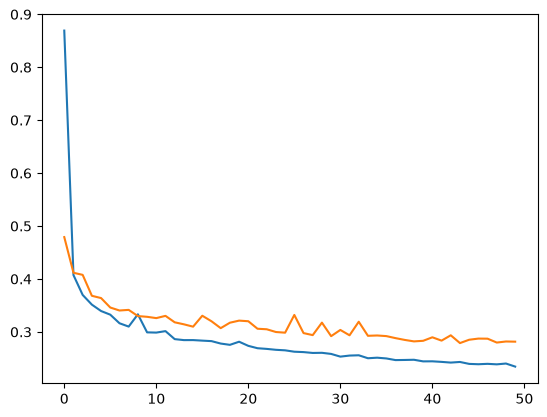

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")



Predict a few test samples and compare with the true values.

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 244us/step


Text(0.5, 1.0, 'Predicted vs Actual houseprices in 100.000$')

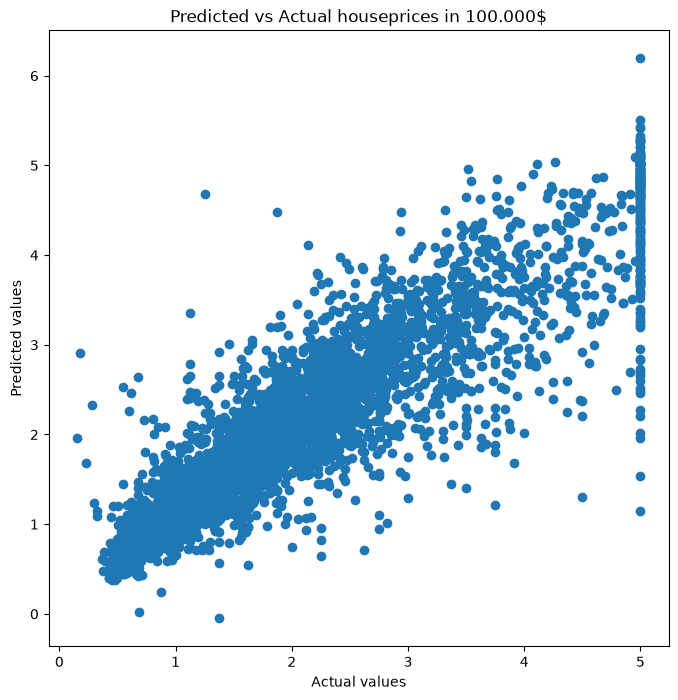

In [16]:
y_pred = model.predict(X_test)

#create a scatter plot of the predicted vs actual values
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Predicted vs Actual houseprices in 100.000$")


Something looks wierd, data may be capped at 500.000, lets take a closer look

In [15]:
#load X and y from the california housing dataset into a pandas dataframe
df = fetch_california_housing(as_frame=True).frame
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


(array([   9.,   14.,   61.,  255.,  538.,  676.,  546.,  803.,  881.,
         706.,  812.,  715.,  836.,  815.,  921.,  960.,  786.,  817.,
         703.,  505.,  620.,  661.,  578.,  508.,  432.,  439.,  463.,
         331.,  320.,  216.,  224.,  232.,  245.,  252.,  286.,  193.,
         160.,  149.,  117.,  133.,  104.,   99.,   80.,   90.,  106.,
          66.,   49.,   51.,   47., 1030.]),
 array([0.14999  , 0.2469904, 0.3439908, 0.4409912, 0.5379916, 0.634992 ,
        0.7319924, 0.8289928, 0.9259932, 1.0229936, 1.119994 , 1.2169944,
        1.3139948, 1.4109952, 1.5079956, 1.604996 , 1.7019964, 1.7989968,
        1.8959972, 1.9929976, 2.089998 , 2.1869984, 2.2839988, 2.3809992,
        2.4779996, 2.575    , 2.6720004, 2.7690008, 2.8660012, 2.9630016,
        3.060002 , 3.1570024, 3.2540028, 3.3510032, 3.4480036, 3.545004 ,
        3.6420044, 3.7390048, 3.8360052, 3.9330056, 4.030006 , 4.1270064,
        4.2240068, 4.3210072, 4.4180076, 4.515008 , 4.6120084, 4.7090088,
        

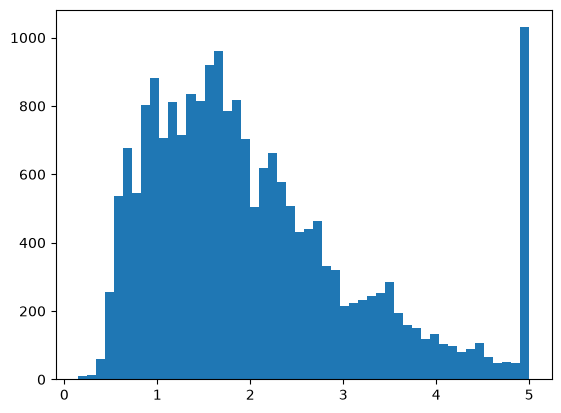

In [21]:
plt.hist(df['MedHouseVal'], bins=50)